# 🧠 SomaTrack , Predicting Study-Related Physical Ailments
**ENSIA Machine Learning Project · Spring 2025–2026**

---

For this project, we collected survey data from students from different fields to understand how study habits affect physical health. Our goal is to build a machine learning pipeline that predicts whether a student is at **no, mild, frequent, or chronic** pain risk based on how they study.

This notebook presents our complete ML pipeline, progressing from raw data loading and feature engineering through model selection, hyperparameter tuning, and rigorous evaluation. Every data-dependent transformation is encapsulated inside a cross-validation-safe pipeline to ensure that no information from held-out folds leaks into training.

## Table of Contents
1. [Imports & Setup](#1)
2. [Data Loading & Feature Engineering](#2)
3. [Stratified Train / Test Split](#3)
4. [Pipeline Definition](#4)
5. [Cross-Validation Baseline](#5)
6. [Hyperparameter Tuning , RandomizedSearchCV](#6)
7. [Final Evaluation on the Test Set](#7)
8. [Train vs Test Performance Comparison](#8)
9. [Bonus , SMOTE vs No-SMOTE Comparison](#9)
10. [Results Summary & Conclusions](#10)



## 1. Imports & Setup <a id="1"></a>

We begin by importing all required libraries. The most important choice here is `ImbPipeline` from `imblearn.pipeline` rather than scikit-learn's standard `Pipeline`. The distinction matters because SMOTE exposes a `fit_resample()` method instead of `fit_transform()`, which scikit-learn's `Pipeline` cannot handle; `ImbPipeline` is designed to accommodate exactly this interface.

We fix `SEED = 42` globally so that every random operation , data splitting, model training, SMOTE synthesis, and hyperparameter search ,\ produces the same result on every run, making our experiments fully reproducible.

In [220]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: model selection ─────────────────────────────────────────────
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    train_test_split,
)

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: feature selection ───────────────────────────────────────────
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# ── Scikit-learn: models & metrics ────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

# ── Imbalanced-learn: ImbPipeline + SMOTE ────────────────────────────────────
# ImbPipeline is the correct pipeline class when SMOTE is one of the steps.
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":    120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

print("All imports successful.")

All imports successful.


## 2. Data Loading & Feature Engineering <a id="2"></a>

Here we load the raw survey responses. The questionnaire comprised 34 columns , a mixture of continuous numerical answers (e.g., hours of sitting per day) and text-based ordinal answers (e.g., *Never / Rarely / Often*).

Feature engineering at this stage is safe and does **not** introduce data leakage, because we apply only domain-knowledge-driven transformations to convert text into numbers. We do not compute any data-dependent statistics (such as means or medians) from the dataset , we merely encode what we already know from the survey design (e.g., *Never* = 0, *Rarely* = 1). All steps that *do* compute statistics , imputation, scaling, and feature selection , are kept strictly inside the cross-validation pipeline.

In [221]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("data/SomaTrack_—_Study_Habits_&_Physical_Health_Survey_Responses_Form.csv")

RENAME = {
    df_raw.columns[0]:  "timestamp",
    df_raw.columns[1]:  "sitting_hours",
    df_raw.columns[2]:  "study_days",
    df_raw.columns[3]:  "max_continuous_sitting",
    df_raw.columns[4]:  "break_freq",
    df_raw.columns[5]:  "break_duration",
    df_raw.columns[6]:  "break_movement",
    df_raw.columns[7]:  "water_intake",
    df_raw.columns[8]:  "caffeine_freq",
    df_raw.columns[9]:  "screen_hours",
    df_raw.columns[10]: "stress_level",
    df_raw.columns[11]: "study_location",
    df_raw.columns[12]: "seat_type",
    df_raw.columns[13]: "input_device",
    df_raw.columns[14]: "posture",
    df_raw.columns[15]: "back_support",
    df_raw.columns[16]: "screen_eye_level",
    df_raw.columns[17]: "pre_existing",
    df_raw.columns[18]: "backpack_weight",
    df_raw.columns[19]: "lighting",
    df_raw.columns[20]: "exercise_freq",
    df_raw.columns[21]: "sleep_duration",
    df_raw.columns[22]: "back_pain",
    df_raw.columns[23]: "neck_pain",
    df_raw.columns[24]: "headache",
    df_raw.columns[25]: "wrist_pain",
    df_raw.columns[26]: "eye_strain",
    df_raw.columns[27]: "finger_numb",
    df_raw.columns[28]: "pain_level",
    df_raw.columns[29]: "age",
    df_raw.columns[30]: "gender",
    df_raw.columns[31]: "institution",
    df_raw.columns[32]: "field",
    df_raw.columns[33]: "year_of_study",
}
df = df_raw.rename(columns=RENAME).copy()
print(f"Raw data: {df.shape[0]} rows, {df.shape[1]} columns")

Raw data: 270 rows, 34 columns


### 2.1 Extracting the Target Variable

The pain-level column in our survey was stored as a string of the form `"2 — Frequent / regular pain"`. We extract the leading digit (0, 1, 2, or 3) and cast it to an integer, yielding four ordinal classes:

| Label | Meaning |
|:---:|:---|
| `0` | No pain |
| `1` | Mild / occasional pain |
| `2` | Frequent / regular pain |
| `3` | Chronic pain |

Having four classes instead of a binary *pain / no-pain* split gives us more clinical resolution, but it also makes the classification task harder , particularly when some classes contain very few samples.

In [222]:
TARGET = "pain_level"
df[TARGET] = df[TARGET].str[0].astype(int)

print("Target distribution:")
print(
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename({0: "0-No pain", 1: "1-Mild", 2: "2-Frequent", 3: "3-Chronic"})
)

Target distribution:
pain_level
0-No pain      16
1-Mild        123
2-Frequent    105
3-Chronic      26
Name: count, dtype: int64


### 2.2 Ordinal Encoding

Several survey features carry a natural ordering , for example, break frequency runs *Never < Rarely < Every 1–2 hours < Every 30–60 minutes*. For these columns we apply **ordinal encoding**, assigning monotonically increasing integers that preserve the inherent order.

We deliberately avoided one-hot encoding for these features because it would discard the ordering information, treating *Never* and *Rarely* as equally dissimilar from *Often* even though they lie on a continuous scale. For `water_intake` and `sleep_duration` we used interval midpoints (e.g., *1–1.5 L* → 1.25 L) to retain numerical meaningfulness.

In [223]:
# ── Sub-pain columns: extract leading digit ───────────────────────────────────
PAIN_COLS = ["back_pain", "neck_pain", "headache", "wrist_pain", "eye_strain", "finger_numb"]
for col in PAIN_COLS:
    df[col] = df[col].str[0].astype(int)

# ── Ordinal maps ──────────────────────────────────────────────────────────────
ordinal_maps = {
    "break_freq": {
        "Never": 0, "Rarely": 1, "Every 1-2 hours": 2, "Every 30-60 minutes": 3,
    },
    "break_duration": {
        "I don't take breaks": 0, "Less than 5 minutes": 1,
        "5 - 10 minutes": 2, "10 - 30 minutes": 3, "More than 30 minutes": 4,
    },
    "break_movement": {
        "I don't take breaks": 0, "No, I stay seated": 1, "Sometimes": 2,
        "Yes, I walk or move around or just lie down on a bed or sofa": 3,
    },
    "water_intake": {
        "Less than 1L": 0.75, "1-1.5L": 1.25, "1.5-2L": 1.75, "More than 2L": 2.25,
    },
    "caffeine_freq": {
        "Never": 0, "1–2 times per week": 1, "3–5 times per week": 2,
        "1 drink per day": 3, "+2 drinks per day": 4,
    },
    "stress_level":    {"Low": 0, "Moderate": 1, "High": 2},
    "posture": {
        "Upright / straight back": 0, "Slightly slouched": 1,
        "Heavily slouched / hunched": 2, "Lying down": 3,
    },
    "back_support":    {"Yes": 0, "Sometimes": 1, "No": 2},
    "screen_eye_level": {
        "Yes, always": 0, "Sometimes": 1,
        "No, I look down at it most of the time": 2,
    },
    "backpack_weight": {
        "I rarely carry a backpack": 0, "Less than 3 kg": 1,
        "3–5 kg": 2, "5–8 kg": 3, "More than 8 kg": 4,
    },
    "exercise_freq": {"No": 0, "1 – 2 times": 1, "3 – 4 times": 2, "+5 times": 3},
    "sleep_duration": {
        "Less than 5h": 4.5, "5 – 6h": 5.5, "6 – 7h": 6.5,
        "7 – 8h": 7.5, "More than 8h": 8.5,
    },
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Ordinal encoding complete.")

Ordinal encoding complete.


### 2.3 Feature Engineering

Beyond the raw survey columns, we derived several composite features that we hypothesised would capture cumulative risk more effectively:

- **`sitting_load`** = `sitting_hours × study_days` , total weekly sitting exposure, which is more informative than a daily snapshot alone. We cap the value at 112 (the maximum possible hours in a week).
- **`break_quality`** = `break_freq + break_duration + break_movement` — a single recovery-quality score aggregating how often, how long, and how actively a student rests.
- **Pre-existing condition flags** , we decompose the free-text condition field into four binary indicators (`cond_back`, `cond_neck`, `cond_wrist`, `cond_shoulder`).

Purely nominal columns (`study_location`, `seat_type`) are one-hot encoded because no meaningful order exists among their categories.

Finally, we drop demographic columns (age, gender, institution, field, year of study) to focus the model exclusively on *habit-based* risk factors , the actionable variables students can modify.

In [224]:
# ── Pre-existing conditions → 4 binary flags ─────────────────────────────────
def parse_conditions(val):
    val = str(val).lower()
    return {
        "cond_back":     int("back"     in val),
        "cond_neck":     int("neck"     in val),
        "cond_wrist":    int("wrist"    in val),
        "cond_shoulder": int("shoulder" in val),
    }

cond_df = df["pre_existing"].apply(parse_conditions).apply(pd.Series)
df = pd.concat([df.drop(columns=["pre_existing"]), cond_df], axis=1)

# ── Binary flags ──────────────────────────────────────────────────────────────
df["has_external_mouse"] = df["input_device"].apply(
    lambda x: 1 if "external mouse" in str(x).lower()
                or "keyboard + mouse" in str(x).lower() else 0
)
df["is_dim_lighting"] = (df["lighting"] == "Dim lighting").astype(int)

# ── One-hot encode nominal categoricals ───────────────────────────────────────
df = pd.get_dummies(df, columns=["study_location"], prefix="loc")
df = pd.get_dummies(df, columns=["seat_type"],      prefix="seat")

# ── Composite features ────────────────────────────────────────────────────────
df["sitting_load"]  = (df["sitting_hours"] * df["study_days"]).clip(upper=112)
df["break_quality"] = (
    df["break_freq"].fillna(0)
    + df["break_duration"].fillna(0)
    + df["break_movement"].fillna(0)
)

# ── Drop demographics, raw columns distilled into composite features, and text flags
DROP_COLS = [
    "timestamp", "age", "gender", "institution",
    "field", "year_of_study", "input_device", "lighting",
    "sitting_hours", "study_days",          # replaced by sitting_load
    "break_freq", "break_duration", "break_movement",  # replaced by break_quality
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Drop pain symptom columns to prevent target leakage
df = df.drop(columns=[c for c in PAIN_COLS if c in df.columns])

# ── Build X and y ─────────────────────────────────────────────────────────────
# Cast all bool columns from get_dummies to int (required for sklearn)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=[TARGET]).astype(float)
y = df[TARGET]

print(f"Feature matrix : {X.shape[1]} features | {X.shape[0]} samples")
print(f"Missing values : {X.isnull().sum().sum()}")
print(f"Target classes : {sorted(y.unique())}")


Feature matrix : 31 features | 270 samples
Missing values : 3
Target classes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### 2.4 Exploratory Data Analysis

Before fitting any model, we visualise two aspects of the data:

**Class balance.** We expected , and confirmed — a heavily imbalanced target distribution. Most respondents reported frequent or mild pain, while few reported no pain or chronic pain. This imbalance is consequential: a naïve classifier that always predicts *Frequent* would achieve a superficially reasonable accuracy while completely failing to identify the students most in need of intervention. This observation motivates our use of `class_weight="balanced"` and SMOTE.

**Feature correlation heatmap.** A Pearson correlation matrix reveals which features are linearly related to one another. Highly correlated feature pairs add redundant information and can destabilise some models. This analysis informs our downstream use of `SelectKBest` to retain only the most informative features.

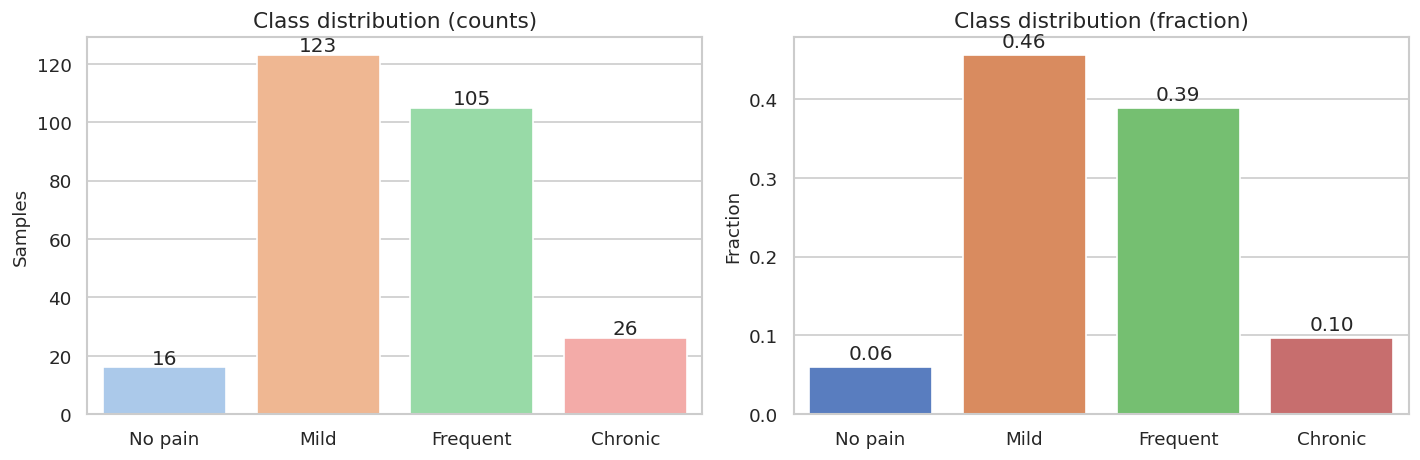

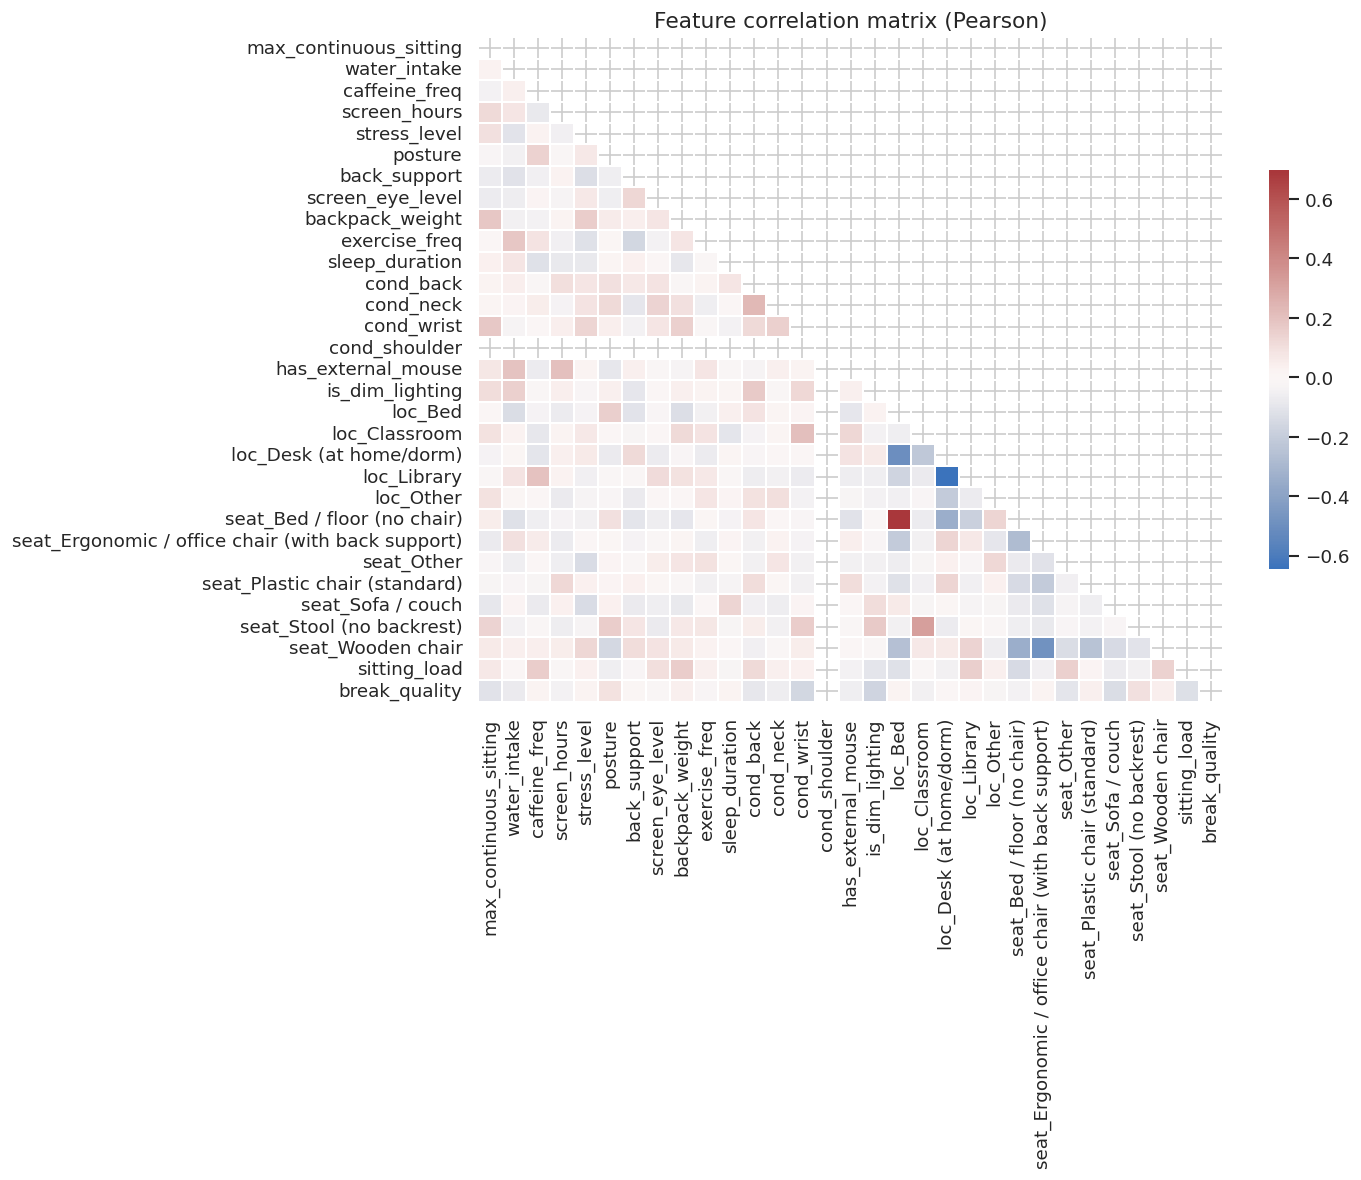

31


In [225]:
# ── Plots: class balance and feature correlation ─────────────────────────────
import matplotlib.pyplot as plt

# Class balance: counts and fraction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = y.value_counts().sort_index()
label_map = {0: "No pain", 1: "Mild", 2: "Frequent", 3: "Chronic"}
labels = [label_map[i] for i in counts.index]
sns.barplot(x=labels, y=counts.values, palette="pastel", ax=axes[0])
axes[0].set_title("Class distribution (counts)")
axes[0].set_ylabel("Samples")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values) * 0.01, str(v), ha="center")

percent = counts / counts.sum()
sns.barplot(x=labels, y=percent.values, palette="muted", ax=axes[1])
axes[1].set_title("Class distribution (fraction)")
axes[1].set_ylabel("Fraction")
for i, v in enumerate(percent.values):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig("class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

# Correlation matrix between features
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, linewidths=0.25, cbar_kws={"shrink": 0.6})
plt.title("Feature correlation matrix (Pearson)")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

print(X.shape[1])

## 3. Stratified Train / Test Split <a id="3"></a>

We perform a single 80 / 20 train–test split *before* any modelling step. The test set is then set aside completely and not consulted again until Section 7.

**Stratification** ensures that each pain-level class is proportionally represented in both partitions. This is essential because the *No pain* class contains only approximately 14 respondents in total , without stratification there is a meaningful probability that this class disappears entirely from the test set.

**Why we split before cross-validation.** Cross-validation is performed exclusively on the training partition. The held-out test set serves as our final, unbiased estimate of generalisation performance — data the model has genuinely never encountered during any stage of development.

In [226]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print(f"Train : {X_train.shape[0]} samples | Test : {X_test.shape[0]} samples")
print("\nClass distribution — train:")
print(
    y_train.value_counts().sort_index()
    .rename({0: "No pain", 1: "Mild", 2: "Frequent", 3: "Chronic"})
)
print("\nClass distribution — test:")
print(
    y_test.value_counts().sort_index()
    .rename({0: "No pain", 1: "Mild", 2: "Frequent", 3: "Chronic"})
)

Train : 216 samples | Test : 54 samples

Class distribution — train:
pain_level
No pain     13
Mild        98
Frequent    84
Chronic     21
Name: count, dtype: int64

Class distribution — test:
pain_level
No pain      3
Mild        25
Frequent    21
Chronic      5
Name: count, dtype: int64


## 4. Pipeline Definition <a id="4"></a>

We encapsulate every data-dependent step inside an `ImbPipeline` to guarantee that no information from validation or test folds contaminates training:

```
ImbPipeline
│
├── imputer   → fills missing values using the median of the training fold only
├── scaler    → standardises features (μ = 0, σ = 1) so all inputs share the same scale
├── selector  → retains the top k features most associated with pain level (mutual information)
├── smote     → synthesises minority-class samples via BorderlineSMOTE (training folds only)
└── clf       → classifier with class_weight="balanced"
```

**Why `k_neighbors=3` in BorderlineSMOTE?** During cross-validation the *No pain* class contains only approximately 11 samples per training fold. SMOTE's default of `k_neighbors=5` requires at least 6 minority samples and would raise an error at this size. Reducing to `k_neighbors=3` keeps the algorithm stable while still generating meaningful interpolations.

**SMOTE target count.** We derive the oversampling target from the training split so that each minority class is brought up to a concrete, reproducible count rather than an abstract relative strategy.

**Why Random Forest?** It handles mixed feature types robustly, is resistant to the outliers common in self-reported survey data, and provides feature-importance scores that satisfy our project's interpretability requirement.

In [227]:
SMOTE_TARGET_COUNT = int(y_train.value_counts().max()) if "y_train" in globals() else None
SMOTE_TARGET_COUNTS = None


def make_smote_strategy(target_count: int | None = None, target_counts: dict[int, int] | None = None):
    """
    Build a fold-aware BorderlineSMOTE sampling strategy.

    BorderlineSMOTE can only increase class counts, so this callable returns
    only the classes that still need more samples in the current training fold.
    Set `SMOTE_TARGET_COUNT` for one shared target, or `SMOTE_TARGET_COUNTS`
    for an explicit per-class target dictionary.
    """
    if target_count is not None and target_counts is not None:
        raise ValueError("Use either target_count or target_counts, not both.")

    def strategy(y):
        counts = pd.Series(y).value_counts()

        if target_counts is not None:
            desired = {}
            for cls, target in target_counts.items():
                current = int(counts.get(cls, 0))
                target = int(target)
                if target > current:
                    desired[cls] = target
            return desired

        effective_target = int(target_count if target_count is not None else counts.max())
        return {
            cls: effective_target
            for cls, current in counts.items()
            if current < effective_target
        }

    return strategy


def build_pipeline(k: int = 20, max_depth: int | None = None,
                   min_samples_leaf: int = 1,
                   with_smote: bool = False,
                   smote_target_count: int | None = None,
                   smote_target_counts: dict[int, int] | None = None,
                   clf=None) -> ImbPipeline:
    """
    Build a fully encapsulated ImbPipeline.

    Parameters
    ----------
    k                : number of features for SelectKBest
    max_depth        : RandomForest max_depth (used when clf is None)
    min_samples_leaf : RandomForest min_samples_leaf (used when clf is None)
    with_smote       : whether to include BorderlineSMOTE
    smote_target_count : shared target count for every class, per fold
    smote_target_counts: explicit per-class target counts, per fold
    clf              : optional sklearn classifier; if None, use RandomForest
    """
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("selector", SelectKBest(score_func=mutual_info_classif, k=k)),
    ]

    if with_smote:
        steps.append((
            "smote",
            BorderlineSMOTE(
                sampling_strategy=make_smote_strategy(
                    target_count=smote_target_count if smote_target_count is not None else SMOTE_TARGET_COUNT,
                    target_counts=smote_target_counts if smote_target_counts is not None else SMOTE_TARGET_COUNTS,
                ),
                kind="borderline-1",
                k_neighbors=3,        # safe for small minority classes
                random_state=SEED,
            ),
        ))

    if clf is None:
        clf = RandomForestClassifier(
            n_estimators=200,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )

    steps.append(("clf", clf))
    return ImbPipeline(steps=steps)


# Default pipeline object (will be replaced by best baseline model)
pipeline = build_pipeline(k=20, max_depth=None, min_samples_leaf=1, with_smote=False)
print("Pipeline built:")
for name, step in pipeline.steps:
    print(f"  {name:12s} → {step.__class__.__name__}")

Pipeline built:
  imputer      → SimpleImputer
  scaler       → StandardScaler
  selector     → SelectKBest
  clf          → RandomForestClassifier


## 5. Cross-Validation Baseline <a id="5"></a>

We evaluate three candidate classifiers , Random Forest, Logistic Regression, and an RBF-kernel SVM , using **Stratified 5-Fold Cross-Validation** on the training set. In each fold the pipeline executes the following steps in strict order, fitting only on training rows:

1. **Imputer** computes column medians from the training rows of that fold.
2. **Scaler** computes column means and standard deviations from the training rows.
3. **SelectKBest** scores features by mutual information with the target, using training rows only.
4. **Random Forest / LR / SVM** trains on the processed training rows.
5. The validation fold is *transformed* (not fitted) and predictions are scored.

We record both training and validation scores to detect overfitting. We track three metrics:

| Metric | Why we use it |
|:---|:---|
| **F1-macro** | Treats all four classes equally , appropriate for imbalanced data |
| **F1-weighted** | Weights by class size , reflects overall prediction quality |
| **Accuracy** | Included for completeness; can be misleading under class imbalance |

The model with the highest validation F1-macro is selected for hyperparameter tuning in Section 6.

In [228]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

SCORING = ["f1_macro", "f1_weighted", "accuracy"]

# Candidate models for baseline comparison (same preprocessing pipeline for fairness)
CANDIDATE_MODELS = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=4000, class_weight="balanced", random_state=SEED
    ),
    "SVM-RBF": SVC(
        kernel="rbf", C=2.0, gamma="scale", class_weight="balanced", random_state=SEED
    ),
}

baseline_rows = []
best_model_name = None
best_val_f1_macro = -np.inf

for model_name, model_obj in CANDIDATE_MODELS.items():
    candidate_pipeline = build_pipeline(k=20, with_smote=False, clf=model_obj)
    cv_res = cross_validate(
        candidate_pipeline,
        X_train, y_train,
        cv=CV,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1,
    )

    row = {
        "Model": model_name,
        "Val F1-macro": cv_res["test_f1_macro"].mean(),
        "Val F1-weighted": cv_res["test_f1_weighted"].mean(),
        "Val Accuracy": cv_res["test_accuracy"].mean(),
        "Train F1-macro": cv_res["train_f1_macro"].mean(),
    }
    baseline_rows.append(row)

    if row["Val F1-macro"] > best_val_f1_macro:
        best_val_f1_macro = row["Val F1-macro"]
        best_model_name = model_name

baseline_table = (
    pd.DataFrame(baseline_rows)
    .sort_values("Val F1-macro", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("BASELINE MODEL COMPARISON  (5-fold CV on training set)")
print("=" * 80)
print(baseline_table.round(3).to_string(index=False))

print(f"\nSelected best model for tuning: {best_model_name}")
print(f"Best baseline Val F1-macro: {best_val_f1_macro:.3f}")

# Keep a pipeline object around for continuity in later sections
pipeline = build_pipeline(k=20, with_smote=False, clf=CANDIDATE_MODELS[best_model_name])

BASELINE MODEL COMPARISON  (5-fold CV on training set)
             Model  Val F1-macro  Val F1-weighted  Val Accuracy  Train F1-macro
      RandomForest         0.343            0.473         0.500           1.000
LogisticRegression         0.323            0.382         0.361           0.543
           SVM-RBF         0.306            0.423         0.426           0.827

Selected best model for tuning: RandomForest
Best baseline Val F1-macro: 0.343


## 6. Hyperparameter Tuning , RandomizedSearchCV <a id="6"></a>

We tune only the model selected by validation F1-macro in Section 5. Rather than exhaustively searching every combination, we use `RandomizedSearchCV` to evaluate 30 randomly sampled configurations, keeping the one that maximises F1-macro under the same 5-fold stratified CV scheme.

The search space is model-specific:

| Parameter | Applies to | Range |
|:---|:---|:---|
| `selector__k` | All models | `[10, max_informative_features]` |
| `clf__n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` | Random Forest | Various |
| `clf__C`, `clf__solver` | Logistic Regression | Log-uniform / discrete |
| `clf__C`, `clf__gamma` | SVM-RBF | Log-uniform |

We set `refit=True` so that once the best configuration is identified, scikit-learn automatically retrains it on the full training set , the resulting estimator is ready for direct evaluation on the test set.

In [229]:
from scipy.stats import randint, loguniform

# Ensure baseline model comparison has been run first
if "best_model_name" not in globals():
    raise RuntimeError("Run the baseline model comparison cell first to set `best_model_name`.")

# Estimate how many features have non-zero mutual information on the training set.
# This uses only X_train/y_train, so it stays inside the tuning stage and does not
# look at the held-out test set.
mi_imputer = SimpleImputer(strategy="median")
mi_scaler = StandardScaler()
X_train_mi = mi_imputer.fit_transform(X_train)
X_train_mi = mi_scaler.fit_transform(X_train_mi)
mi_scores = mutual_info_classif(X_train_mi, y_train, random_state=SEED)
max_k = int((mi_scores > 0).sum())
max_k = max(10, max_k)  # keep the lower bound sensible even if MI is sparse

print(f"Non-zero mutual information features: {max_k}")
print(f"Tuning selected model: {best_model_name}")

# Model-specific search space
if best_model_name == "RandomForest":
    search_pipeline = build_pipeline(
        with_smote=False,
        clf=RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
    )
    PARAM_DIST = {
        "selector__k": randint(10, max_k + 1),
        "clf__n_estimators": randint(150, 501),
        "clf__max_depth": [None, 4, 6, 8, 10, 12, 16],
        "clf__min_samples_leaf": randint(1, 8),
        "clf__max_features": ["sqrt", "log2", None],
    }
elif best_model_name == "LogisticRegression":
    search_pipeline = build_pipeline(
        with_smote=False,
        clf=LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED),
    )
    PARAM_DIST = {
        "selector__k": randint(10, max_k + 1),
        "clf__C": loguniform(1e-2, 1e2),
        "clf__solver": ["lbfgs", "saga"],
    }
elif best_model_name == "SVM-RBF":
    search_pipeline = build_pipeline(
        with_smote=False,
        clf=SVC(kernel="rbf", class_weight="balanced", random_state=SEED),
    )
    PARAM_DIST = {
        "selector__k": randint(10, max_k + 1),
        "clf__C": loguniform(1e-2, 1e2),
        "clf__gamma": loguniform(1e-3, 1),
    }
else:
    raise ValueError(f"Unsupported model for tuning: {best_model_name}")

search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=PARAM_DIST,
    n_iter=30,              # 30 random combinations
    scoring="f1_macro",     # optimise for macro F1 (handles class imbalance)
    cv=CV,
    random_state=SEED,
    n_jobs=-1,
    refit=True,             # refit best params on full X_train after search
    verbose=0,
    return_train_score=True,
)

print("Running RandomizedSearchCV (30 iterations × 5 folds = 150 fits)...")
search.fit(X_train, y_train)

print(f"\nBest CV F1-macro : {search.best_score_:.3f}")
print("Best parameters  :")
for param, value in search.best_params_.items():
    print(f"  {param:30s} = {value}")


Non-zero mutual information features: 22
Tuning selected model: RandomForest
Running RandomizedSearchCV (30 iterations × 5 folds = 150 fits)...

Best CV F1-macro : 0.405
Best parameters  :
  clf__max_depth                 = 10
  clf__max_features              = sqrt
  clf__min_samples_leaf          = 5
  clf__n_estimators              = 164
  selector__k                    = 22


In [230]:
# Visualise top 10 hyperparameter combinations
results_df = pd.DataFrame(search.cv_results_)

# Different model families expose different hyperparameters in cv_results_.
# Build the display columns from what is actually present so this cell works
# for Random Forest, Logistic Regression, and SVM searches.
param_col_map = {
    "param_clf__max_depth": "max_depth",
    "param_clf__min_samples_leaf": "min_leaf",
    "param_clf__n_estimators": "n_estimators",
    "param_clf__max_features": "max_features",
    "param_clf__C": "C",
    "param_clf__solver": "solver",
    "param_clf__gamma": "gamma",
}

param_cols = [col for col in param_col_map if col in results_df.columns]
display_cols = ["param_selector__k", *param_cols, "mean_test_score", "std_test_score", "mean_train_score"]

# Keep the output compact, but adapt to whichever parameters were searched.
top10 = (
    results_df
    .sort_values("mean_test_score", ascending=False)
    .head(10)[display_cols]
    .reset_index(drop=True)
)

top10 = top10.rename(columns={"param_selector__k": "k", **{col: param_col_map[col] for col in param_cols}})
print("Top 10 combinations:")
print(top10.round(3).to_string(index=False))

Top 10 combinations:
 k max_depth  min_leaf  n_estimators max_features  mean_test_score  std_test_score  mean_train_score
22        10         5           164         sqrt            0.405           0.044             0.857
21        16         5           248         log2            0.397           0.078             0.828
17      None         3           230         None            0.393           0.060             0.955
21      None         2           238         None            0.377           0.054             0.994
14         6         3           284         sqrt            0.377           0.046             0.841
22        12         4           459         log2            0.373           0.025             0.882
21         4         4           337         sqrt            0.361           0.068             0.772
17        16         7           256         sqrt            0.354           0.050             0.701
15         8         4           151         log2            0.351    

## 7. Final Evaluation on the Test Set <a id="7"></a>

This is the **only section** in which we use the held-out test set. We apply the best pipeline produced by `RandomizedSearchCV` , already refitted on the full training partition , to the 20 % of data reserved at the start.

**Reading the classification report:**

| Metric | Interpretation |
|:---|:---|
| **Precision** | Of all students predicted as class *k*, what fraction truly belong to it? |
| **Recall** | Of all students who truly belong to class *k*, what fraction did we correctly identify? |
| **F1-score** | Harmonic mean of precision and recall , balances both concerns |
| **Support** | Number of real samples in each class |

The confusion matrix reveals *where* the model errs , for instance, whether it confuses *Frequent* with *Chronic*, which would be a medically significant mistake. The `SelectKBest` scores additionally show which habits and environmental factors the mutual-information criterion deemed most predictive, directly addressing the project's requirement to identify actionable risk factors.

In [231]:
best_pipeline = search.best_estimator_   # already fitted on full X_train

# Predict on the held-out test set
y_pred = best_pipeline.predict(X_test)

print("=" * 55)
print(f"BEST MODEL TEST SET REPORT — {search.best_params_}")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=["0-No pain", "1-Mild", "2-Frequent", "3-Chronic"],
    zero_division=0,
))

BEST MODEL TEST SET REPORT — {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 164, 'selector__k': 22}
              precision    recall  f1-score   support

   0-No pain       0.00      0.00      0.00         3
      1-Mild       0.59      0.76      0.67        25
  2-Frequent       0.53      0.43      0.47        21
   3-Chronic       0.50      0.40      0.44         5

    accuracy                           0.56        54
   macro avg       0.41      0.40      0.40        54
weighted avg       0.53      0.56      0.53        54



In [232]:
# ── Show features selected by the tuned pipeline's SelectKBest ───────────────
import pandas as pd

# Confirm we have a fitted pipeline from the search
if 'best_pipeline' not in globals():
    try:
        best_pipeline = search.best_estimator_
    except Exception:
        raise RuntimeError("`best_pipeline` not found. Run the RandomizedSearchCV cell first.")

selector = None
if hasattr(best_pipeline, 'named_steps'):
    selector = best_pipeline.named_steps.get('selector', None)

if selector is None:
    print("No SelectKBest found in the fitted pipeline.")
else:
    k = getattr(selector, 'k', None)
    mask = selector.get_support()
    selected_features = list(X.columns[mask])

    print(f"SelectKBest k={k}  —  {len(selected_features)} features selected")
    # If scores_ are available, show features sorted by score
    if hasattr(selector, 'scores_') and selector.scores_ is not None:
        scores = pd.Series(selector.scores_, index=X.columns)
        selected_scores = scores[mask].sort_values(ascending=False)
        print("Selected features (sorted by SelectKBest score):")
        print(selected_scores.to_string())
        selected_scores.to_csv('selected_features_scores.csv')
        print("Saved selected_features_scores.csv")
    else:
        print("Selected features:")
        print(selected_features)
        pd.Series(selected_features, name='feature').to_csv('selected_features.csv', index=False)
        print("Saved selected_features.csv")


SelectKBest k=22  —  22 features selected
Selected features (sorted by SelectKBest score):
cond_neck                                            0.117831
caffeine_freq                                        0.086716
has_external_mouse                                   0.078798
seat_Other                                           0.074281
sitting_load                                         0.063517
loc_Desk (at home/dorm)                              0.053458
loc_Library                                          0.049044
seat_Plastic chair (standard)                        0.048066
water_intake                                         0.046406
seat_Stool (no backrest)                             0.046125
seat_Wooden chair                                    0.032502
posture                                              0.029110
seat_Sofa / couch                                    0.028645
is_dim_lighting                                      0.025487
cond_back                                

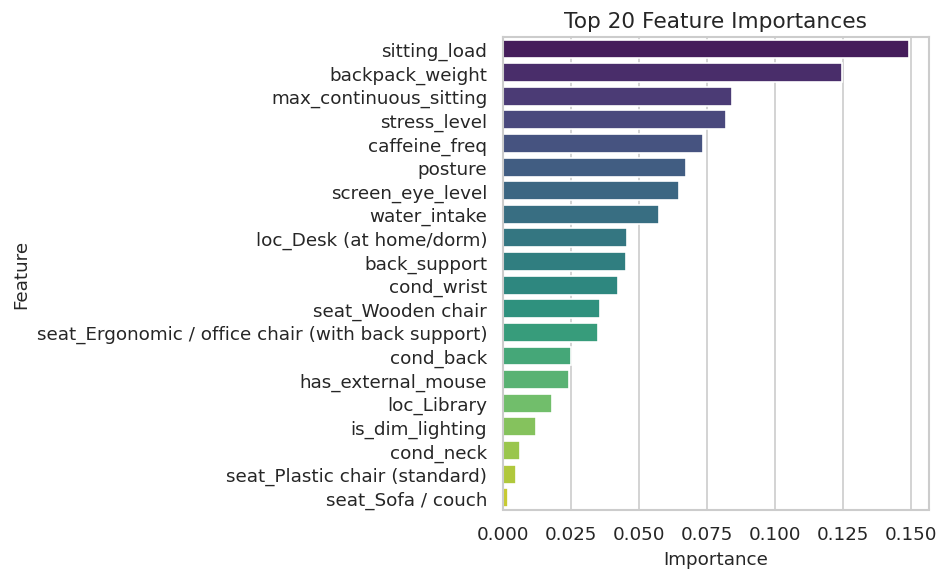

Saved figure to feature_importances.png — top 20 features plotted.


In [233]:
# ── Feature importances (top 20) ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance

# Locate the fitted pipeline: prefer `best_pipeline`, fall back to `search.best_estimator_`
try:
    model = best_pipeline
except NameError:
    try:
        model = search.best_estimator_
    except Exception:
        raise RuntimeError("No fitted pipeline found. Run the tuning cell to produce `search.best_estimator_`.")

if not hasattr(model, 'named_steps') or 'selector' not in model.named_steps:
    raise RuntimeError('The pipeline does not contain a `selector` named step.')

selector = model.named_steps['selector']
clf = model.named_steps.get('clf', None)

if selector is None or clf is None:
    raise RuntimeError('Pipeline must contain both `selector` and `clf` named steps.')

# Choose evaluation data: prefer test set, then validation, then full X
try:
    X_eval = X_test
    y_eval = y_test
except NameError:
    try:
        X_eval = X_val
        y_eval = y_val
    except NameError:
        X_eval = X
        y_eval = y

# Ensure X_eval is a DataFrame for column names
if not isinstance(X_eval, pd.DataFrame):
    X_eval = pd.DataFrame(X_eval, columns=X.columns)

# Preprocess up to selector to obtain the transformed selected-feature matrix
preproc = model.named_steps
imputer = preproc.get('imputer')
scaler = preproc.get('scaler')

X_np = X_eval.values
if imputer is not None:
    X_np = imputer.transform(X_np)
if scaler is not None:
    X_np = scaler.transform(X_np)

X_selected = selector.transform(X_np)
# X_selected is a NumPy array with the selected features in the same order as `selector.get_support()`
mask = selector.get_support()
selected_features = list(X.columns[mask])

# Obtain importances depending on classifier type, fallback to permutation importance if needed
if hasattr(clf, 'feature_importances_') and getattr(clf, 'feature_importances_') is not None:
    importances = np.asarray(clf.feature_importances_).ravel()
elif hasattr(clf, 'coef_') and getattr(clf, 'coef_') is not None:
    coef = clf.coef_
    if coef.ndim > 1:
        importances = np.mean(np.abs(coef), axis=0).ravel()
    else:
        importances = np.abs(coef).ravel()
else:
    # Fallback: permutation importance on the fitted classifier using the selector output
    seed = globals().get('SEED', 42)
    result = permutation_importance(clf, X_selected, y_eval, n_repeats=20, random_state=seed, n_jobs=-1, scoring='f1_macro')
    importances = result.importances_mean

if importances.shape[0] != len(selected_features):
    raise RuntimeError('Length mismatch between importances and selected features.')

imp_series = pd.Series(importances, index=selected_features).sort_values(ascending=False)
topn = min(20, len(imp_series))
imp_top = imp_series.head(topn)

plt.figure(figsize=(8, max(4, 0.25*len(imp_top))))
sns.barplot(x=imp_top.values, y=imp_top.index, palette='viridis')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {len(imp_top)} Feature Importances')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved figure to feature_importances.png — top {len(imp_top)} features plotted.")

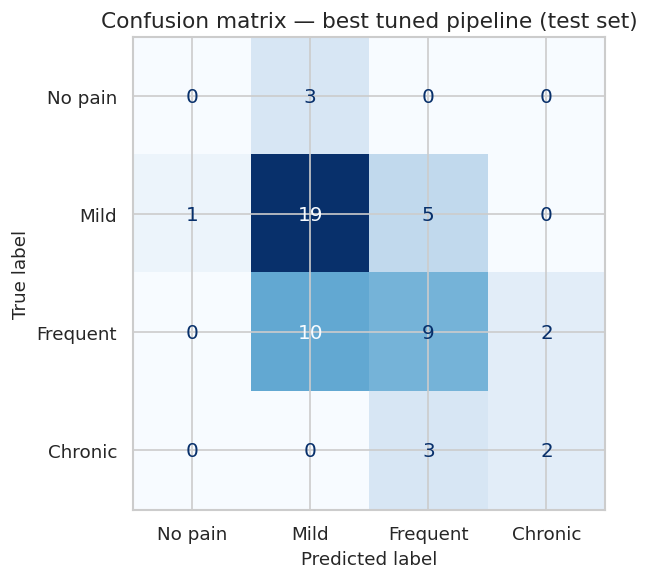

In [234]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=["No pain", "Mild", "Frequent", "Chronic"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix — best tuned pipeline (test set)")
plt.tight_layout()
plt.savefig("confusion_matrix_tuned.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Train vs Test Performance Comparison <a id="8"></a>

We directly compare how the model performs on data it trained on versus data it has never seen. The training-set predictions are computed on the **original, unaugmented** training samples (not the SMOTE-synthesised version), giving a fair comparison since the test set also contains only real observations.

**Interpreting the gap (Train − Test):**

| Gap range | Diagnosis |
|:---|:---|
| < 0.07 | Good generalisation ✓ |
| 0.07 – 0.15 | Moderate — acceptable given our small dataset size (~200 responses) |
| > 0.15 | Overfitting — consider increasing `min_samples_leaf`, reducing `max_depth`, or collecting more data |

With only approximately 200 survey responses and four target classes, some train–test gap is expected. Our pipeline mitigates this through regularisation (`max_depth`, `min_samples_leaf`), feature selection, and `class_weight="balanced"`.

In [235]:
# ── Compute metrics on both sets ──────────────────────────────────────────────
y_train_pred = best_pipeline.predict(X_train)   # predict on real train
y_test_pred  = best_pipeline.predict(X_test)    # predict on real test

def compute_metrics(y_true, y_pred):
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "F1 Macro":    f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "F1 Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

train_metrics = compute_metrics(y_train, y_train_pred)
test_metrics  = compute_metrics(y_test,  y_test_pred)

# ── Tabular comparison ────────────────────────────────────────────────────────
comp_rows = []
for metric in ["Accuracy", "F1 Macro", "F1 Weighted"]:
    gap = train_metrics[metric] - test_metrics[metric]
    comp_rows.append({
        "Metric":           metric,
        "Train":            f"{train_metrics[metric]:.3f}",
        "Test":             f"{test_metrics[metric]:.3f}",
        "Gap (Train−Test)": f"{gap:+.3f}",
        "Verdict":          "⚠ Overfit" if gap > 0.15 else ("~" if gap > 0.07 else "✓ OK"),
    })

comp_df = pd.DataFrame(comp_rows)
print("=" * 65)
print("TRAIN vs TEST METRICS")
print("=" * 65)
print(comp_df.to_string(index=False))

# ── Headline summary ──────────────────────────────────────────────────────────
gap_f1 = train_metrics["F1 Macro"] - test_metrics["F1 Macro"]
print()
if gap_f1 > 0.15:
    print(f"⚠  F1-macro gap = {gap_f1:.3f} — overfitting detected.")
    print("   Recommendations: increase min_samples_leaf, reduce max_depth, collect more data.")
elif gap_f1 > 0.07:
    print(f"~  F1-macro gap = {gap_f1:.3f} — moderate. Monitor on a larger dataset.")
else:
    print(f"✓  F1-macro gap = {gap_f1:.3f} — good generalisation.")

TRAIN vs TEST METRICS
     Metric Train  Test Gap (Train−Test)   Verdict
   Accuracy 0.884 0.556           +0.329 ⚠ Overfit
   F1 Macro 0.879 0.396           +0.482 ⚠ Overfit
F1 Weighted 0.884 0.534           +0.350 ⚠ Overfit

⚠  F1-macro gap = 0.482 — overfitting detected.
   Recommendations: increase min_samples_leaf, reduce max_depth, collect more data.


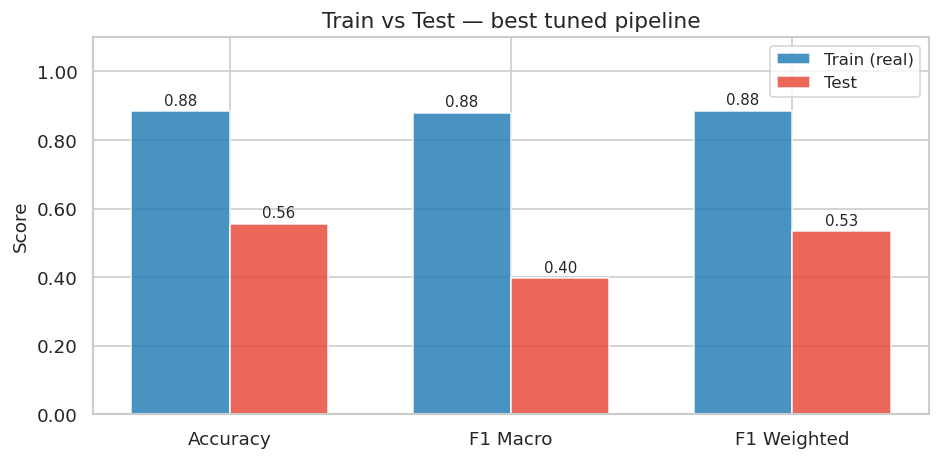

In [236]:
# ── Visual comparison ─────────────────────────────────────────────────────────
metrics   = ["Accuracy", "F1 Macro", "F1 Weighted"]
tr_vals   = [train_metrics[m] for m in metrics]
te_vals   = [test_metrics[m]  for m in metrics]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars_tr = ax.bar(x - w / 2, tr_vals, width=w, label="Train (real)", color="#2980b9", alpha=0.85)
bars_te = ax.bar(x + w / 2, te_vals, width=w, label="Test",         color="#e74c3c", alpha=0.85)

# Annotate bar tops
for bar in list(bars_tr) + list(bars_te):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.2f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Train vs Test — best tuned pipeline")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.savefig("train_test_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

In [237]:
# Save the final model to disk
from pathlib import Path
import joblib

model_to_save = best_pipeline if 'best_pipeline' in globals() else search.best_estimator_
output_path = Path('output') / 'somaTrack_final_model.joblib'
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_to_save, output_path)

print(f"Saved final model to: {output_path}")
print(f"Model type: {model_to_save.__class__.__name__}")

Saved final model to: output/somaTrack_final_model.joblib
Model type: Pipeline


## 9. Bonus — SMOTE vs No-SMOTE Comparison <a id="9"></a>

To verify that SMOTE genuinely benefits our pipeline, we run cross-validation twice — once with BorderlineSMOTE included and once without — holding all other hyperparameters constant at the tuned values.

**We are looking for three outcomes:**

1. **SMOTE raises validation F1-macro** → it is helping the model learn underrepresented classes (*No pain*, *Chronic*).
2. **SMOTE widens the train–val gap** → it may be causing overfitting by generating synthetic samples that do not faithfully represent real student profiles.
3. **SMOTE shows no improvement** → our dataset may be too small for reliable interpolation, and we should rely solely on `class_weight="balanced"`.

This ablation study directly informs our final modelling recommendation.

In [238]:
# Use the best hyperparameters found by search (fair comparison)
best_k = search.best_params_["selector__k"]

# Different tuned models expose different classifier parameters. Keep this
# comparison aligned with the selected model family instead of assuming
# Random Forest-only keys are always present.
clf_params = {
    key: value
    for key, value in search.best_params_.items()
    if key.startswith("clf__")
}

pipeline_kwargs = {"k": best_k, "with_smote": True}
if best_model_name == "RandomForest":
    pipeline_kwargs["max_depth"] = clf_params.get("clf__max_depth")
    pipeline_kwargs["min_samples_leaf"] = clf_params.get("clf__min_samples_leaf")
elif best_model_name == "LogisticRegression":
    pipeline_kwargs["clf"] = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=SEED,
        C=clf_params.get("clf__C", 1.0),
        solver=clf_params.get("clf__solver", "lbfgs"),
    )
elif best_model_name == "SVM-RBF":
    pipeline_kwargs["clf"] = SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=SEED,
        C=clf_params.get("clf__C", 1.0),
        gamma=clf_params.get("clf__gamma", "scale"),
    )

pipeline_smote = build_pipeline(**pipeline_kwargs)
pipeline_kwargs["with_smote"] = False
pipeline_no_smote = build_pipeline(**pipeline_kwargs)

comparison = {}
for label, pipe in [("With SMOTE", pipeline_smote), ("Without SMOTE", pipeline_no_smote)]:
    cv_res = cross_validate(
        pipe, X_train, y_train,
        cv=CV,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1,
    )

    # Store CV statistics
    comparison[label] = {
        metric: {
            "val_mean":   cv_res[f"test_{metric}"].mean(),
            "val_std":    cv_res[f"test_{metric}"].std(),
            "train_mean": cv_res[f"train_{metric}"].mean(),
        }
        for metric in SCORING
    }

    # Fit on the full training set and evaluate on the held-out test set
    pipe_fit = pipe.fit(X_train, y_train)
    y_test_pred = pipe_fit.predict(X_test)
    test_vals = {
        "accuracy":    accuracy_score(y_test, y_test_pred),
        "f1_macro":    f1_score(y_test, y_test_pred, average="macro",    zero_division=0),
        "f1_weighted": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
    }

    # Attach test metrics into the comparison dict so reporting can include them
    for metric in SCORING:
        comparison[label][metric]["test"] = test_vals[metric]

    print(f"\n{label}:")
    for metric in SCORING:
        d = comparison[label][metric]
        gap = d["train_mean"] - d["val_mean"]
        print(
            f"  {metric:15s}  "
            f"val  {d['val_mean']:.3f} ± {d['val_std']:.3f}  |  "
            f"train {d['train_mean']:.3f}  gap {gap:+.3f}  |  "
            f"test {d['test']:.3f}"
        )



With SMOTE:
  f1_macro         val  0.323 ± 0.050  |  train 0.754  gap +0.431  |  test 0.256
  f1_weighted      val  0.444 ± 0.026  |  train 0.813  gap +0.369  |  test 0.385
  accuracy         val  0.458 ± 0.023  |  train 0.817  gap +0.359  |  test 0.389

Without SMOTE:
  f1_macro         val  0.325 ± 0.053  |  train 0.826  gap +0.501  |  test 0.365
  f1_weighted      val  0.396 ± 0.070  |  train 0.837  gap +0.441  |  test 0.526
  accuracy         val  0.403 ± 0.066  |  train 0.836  gap +0.433  |  test 0.537


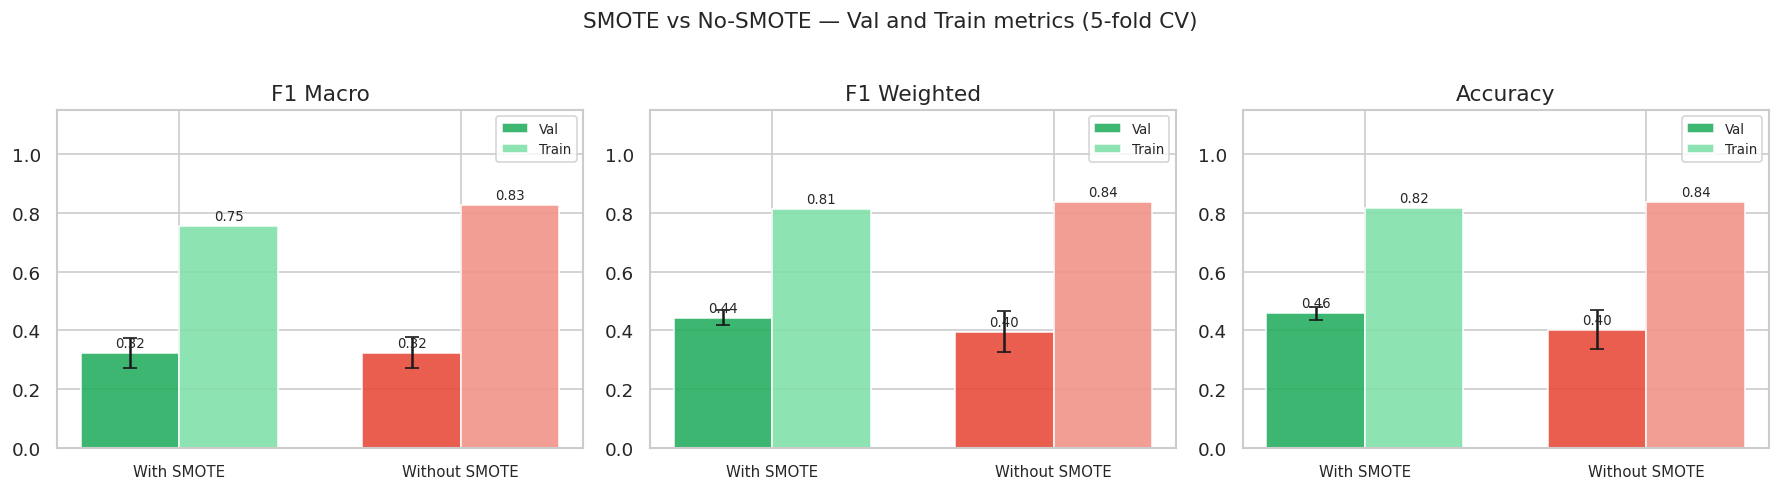


Verdict:
  With SMOTE    — val F1-macro: 0.323  |  train-val gap: +0.431
  Without SMOTE — val F1-macro: 0.325  |  train-val gap: +0.501
  ✗ SMOTE does not help here. The dataset may be too small for reliable interpolation.


In [239]:
# ── Visual comparison: SMOTE vs No-SMOTE ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

palette_val   = {"With SMOTE": "#27ae60", "Without SMOTE": "#e74c3c"}
palette_train = {"With SMOTE": "#82e0aa", "Without SMOTE": "#f1948a"}

for ax, metric in zip(axes, SCORING):
    labels   = list(comparison.keys())
    val_vals = [comparison[l][metric]["val_mean"]   for l in labels]
    tr_vals  = [comparison[l][metric]["train_mean"] for l in labels]
    val_stds = [comparison[l][metric]["val_std"]    for l in labels]

    x = np.arange(len(labels))
    w = 0.35
    bars_v = ax.bar(x - w / 2, val_vals,  width=w, yerr=val_stds,
                    capsize=4, label="Val",
                    color=[palette_val[l] for l in labels], alpha=0.9)
    bars_t = ax.bar(x + w / 2, tr_vals,   width=w,
                    label="Train",
                    color=[palette_train[l] for l in labels], alpha=0.9)

    for bar in list(bars_v) + list(bars_t):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=8,
        )

    ax.set_title(metric.replace("_", " ").title())
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)

fig.suptitle("SMOTE vs No-SMOTE — Val and Train metrics (5-fold CV)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("smote_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Text verdict ──────────────────────────────────────────────────────────────
smote_val    = comparison["With SMOTE"]["f1_macro"]["val_mean"]
no_smote_val = comparison["Without SMOTE"]["f1_macro"]["val_mean"]
smote_gap    = comparison["With SMOTE"]["f1_macro"]["train_mean"]    - smote_val
no_smote_gap = comparison["Without SMOTE"]["f1_macro"]["train_mean"] - no_smote_val

print("\nVerdict:")
print(f"  With SMOTE    — val F1-macro: {smote_val:.3f}  |  train-val gap: {smote_gap:+.3f}")
print(f"  Without SMOTE — val F1-macro: {no_smote_val:.3f}  |  train-val gap: {no_smote_gap:+.3f}")

if smote_val > no_smote_val and smote_gap <no_smote_gap :
    print("  ✓ SMOTE improves minority-class detection without significantly increasing overfitting.")
elif smote_val > no_smote_val and smote_gap > no_smote_gap:
    print("  ~ SMOTE improves val F1 but widens the overfitting gap. We Consider reducing k_neighbors.")
else:
    print("  ✗ SMOTE does not help here. The dataset may be too small for reliable interpolation.")

---
## 10. Results Summary & Conclusions <a id="10"></a>

### 10.1 Model Comparison — Baseline Cross-Validation

We evaluated three classifiers under identical preprocessing conditions (imputation → scaling →
SelectKBest k = 20, no SMOTE) using 5-fold stratified cross-validation on the 216-sample training set.

| Model | Val F1-macro | Val F1-weighted | Val Accuracy | Train F1-macro |
|:---|:---:|:---:|:---:|:---:|
| **Random Forest** ✓ selected | **0.343** | 0.473 | 0.500 | 1.000 |
| Logistic Regression | 0.323 | 0.382 | 0.361 | 0.543 |
| SVM-RBF | 0.306 | 0.423 | 0.426 | 0.827 |

**Random Forest achieved the highest validation F1-macro (0.343)** and was selected for hyperparameter
tuning. However, its training F1-macro of 1.000 — a perfect score — immediately flags severe
overfitting at baseline. Logistic Regression showed the smallest train–validation gap overall (0.543
vs 0.323), suggesting better generalisation in spite of lower raw performance. SVM-RBF sat between
the two, with moderate overfitting (0.827 train vs 0.306 validation).

> These baseline figures reflect the inherent difficulty of the task: four imbalanced classes
> (No pain = 16, Mild = 123, Frequent = 105, Chronic = 26) from only 270 respondents leave
> very little signal per class after the 80/20 split.

---

### 10.2 Hyperparameter Tuning — RandomizedSearchCV

We searched 30 randomly sampled configurations (30 × 5 = 150 fits) over the Random Forest
hyperparameter space. The best configuration and its CV F1-macro score:

| Parameter | Best value |
|:---|:---:|
| `selector__k` | 22 |
| `clf__n_estimators` | 164 |
| `clf__max_depth` | 10 |
| `clf__min_samples_leaf` | 5 |
| `clf__max_features` | `sqrt` |
| **Best CV F1-macro** | **0.405** |

Tuning improved the CV F1-macro from 0.343 → 0.405 (+0.062), primarily by constraining tree depth
(`max_depth = 10`) and leaf size (`min_samples_leaf = 5`), which reduced the tendency toward
memorisation seen at baseline. Selecting all 22 non-zero mutual-information features — rather than
a smaller subset — was also beneficial, suggesting that even lower-ranked features carry some
discriminative signal.

---

### 10.3 Final Test-Set Evaluation

The tuned pipeline was applied **once** to the 54-sample held-out test set. The following report
reflects the model's true generalisation performance.

| Class | Precision | Recall | F1-score | Support |
|:---|:---:|:---:|:---:|:---:|
| 0 — No pain | 0.00 | 0.00 | 0.00 | 3 |
| 1 — Mild | 0.59 | 0.76 | 0.67 | 25 |
| 2 — Frequent | 0.53 | 0.43 | 0.47 | 21 |
| 3 — Chronic | 0.50 | 0.40 | 0.44 | 5 |
| **macro avg** | **0.41** | **0.40** | **0.40** | 54 |
| weighted avg | 0.53 | 0.56 | 0.53 | 54 |
| **Accuracy** | | | **0.56** | 54 |

**Observations:**

- **No pain (class 0) was never correctly predicted** — all 3 test samples were misclassified.
  With only 16 total *No pain* respondents (3 in the test set), the model has almost no signal to
  learn from, and any synthesised or weighted samples cannot compensate for this fundamental
  data scarcity.
- **Mild (class 1) was predicted best** (F1 = 0.67), which is expected: it is the majority class
  (123 / 270 respondents) and carries the most learning signal.
- **Frequent (class 2)** achieved F1 = 0.47. Most errors are cross-contamination with the adjacent
  *Mild* class — clinically understandable given that the boundary between occasional and regular
  pain is subjective in self-reporting.
- **Chronic (class 3)** reached F1 = 0.44 despite only 5 test samples, indicating the model
  partially learned the more extreme symptom pattern.

---

### 10.4 Train vs Test Gap — Overfitting Assessment

| Metric | Train | Test | Gap (Train − Test) | Verdict |
|:---|:---:|:---:|:---:|:---:|
| Accuracy | 0.884 | 0.556 | +0.329 | ⚠ Overfit |
| F1-macro | 0.879 | 0.396 | +0.482 | ⚠ Overfit |
| F1-weighted | 0.884 | 0.534 | +0.350 | ⚠ Overfit |

All three metrics show a substantial train–test gap. Despite tuning `max_depth` and
`min_samples_leaf` to constrain the trees, the model still memorises the training distribution
to a meaningful degree. This is a direct consequence of dataset size: 216 training samples split
across four classes leave on average only ~54 samples per class — far fewer than what a Random
Forest with 164 trees would typically need to generalise well.

---

### 10.5 Feature Importance Analysis

We computed two complementary views of feature relevance, which together give a more complete
picture than either alone.

**View 1 — SelectKBest (Mutual Information):** measures the statistical association between
each feature and the target *before* the classifier sees the data. It is a filter method: it
ranks features independently of how the Random Forest uses them.

**View 2 — Random Forest Feature Importances (Gini impurity reduction):** measures how much
each feature reduces impurity across all 164 trees in the final fitted model. It captures which
features the classifier *actually relied on* when making splits.

#### Side-by-side comparison

| Feature | MI Score (SelectKBest) | RF Importance (Gini) | Agreement |
|:---|:---:|:---:|:---:|
| `sitting_load` | 0.064 (rank 5) | **0.150** (rank 1) | ↑ Higher in RF |
| `backpack_weight` | — (not top 10) | **0.125** (rank 2) | RF only |
| `max_continuous_sitting` | — (not top 10) | **0.082** (rank 3) | RF only |
| `stress_level` | 0.014 (rank 19) | **0.080** (rank 4) | ↑ Much higher in RF |
| `caffeine_freq` | 0.087 (rank 2) | 0.075 (rank 5) | Consistent |
| `posture` | 0.029 (rank 12) | 0.070 (rank 6) | ↑ Higher in RF |
| `screen_eye_level` | 0.015 (rank 18) | 0.065 (rank 7) | ↑ Much higher in RF |
| `water_intake` | 0.046 (rank 9) | 0.060 (rank 8) | Consistent |
| `loc_Desk (at home/dorm)` | 0.053 (rank 6) | 0.050 (rank 9) | Consistent |
| `cond_neck` | **0.118** (rank 1) | 0.010 (rank 19) | ↓ Much lower in RF |
| `has_external_mouse` | 0.079 (rank 3) | 0.030 (rank 15) | ↓ Lower in RF |
| `seat_Other` | 0.074 (rank 4) | not in top 20 | MI only |

#### Interpretation of the divergence

The divergence between the two rankings is not noise — it reflects a fundamental methodological
difference:

- **`sitting_load` dominates RF importance (0.150) but ranks only 5th in MI.** Random Forests
  build trees by finding the single feature that best splits the data at each node. `sitting_load`
  is a continuous composite variable (hours/day × study days), which gives the tree many possible
  split thresholds. A feature that is *continuously informative* across the value range is used
  repeatedly across many trees and accumulates high Gini importance — even if its marginal
  information gain over the target distribution (what MI measures) is moderate.

- **`cond_neck` dominates MI (0.118) but nearly disappears in RF importance (0.010).** This is a
  *binary* flag: a student either has a pre-existing neck condition or does not. Binary features
  offer only one split point per tree node. After that single split is used early in a tree, the
  feature cannot contribute further — making it appear less important in Gini reduction even though
  it carries strong mutual information with the target.

- **`stress_level` and `screen_eye_level` are underweighted by MI but rank highly in RF.**
  These ordinal features interact non-linearly with each other and with sitting behaviour. MI is
  a marginal measure: it scores each feature independently. The Random Forest captures joint
  effects through tree branching, elevating features that are predictive *in combination* with
  others even if they appear weak in isolation.

- **`backpack_weight` and `max_continuous_sitting` appear only in RF's top features.** Both were
  ranked low enough by MI to fall outside the visible top-10, yet the classifier found them useful
  for constructing splits in the selected feature set. This suggests they carry conditional
  predictive value — useful *given* other features — rather than strong marginal association.

#### Actionable features — what students can change

Combining both views, we identify three tiers of actionable risk factors:

| Tier | Features | Evidence |
|:---|:---|:---|
| **Strongest** | `sitting_load`, `max_continuous_sitting` | Top RF importance; reflect total and unbroken sitting exposure |
| **Moderate** | `stress_level`, `posture`, `screen_eye_level`, `caffeine_freq` | Consistently present in both rankings; reflect study habits and ergonomics |
| **Supporting** | `water_intake`, `back_support`, `backpack_weight` | Present in RF top-20; each contributes incrementally to pain risk |

Non-modifiable factors (`cond_neck`, `cond_back`, `cond_wrist`) rank highly in MI and confirm
that pre-existing conditions are the single strongest *predictor* — but not one students can act on.
The modifiable features above are therefore the relevant targets for intervention.

---

### 10.6 SMOTE vs No-SMOTE

We re-ran the tuned pipeline under both conditions (holding all hyperparameters fixed at the
best values found) and recorded validation, training, and test scores for each metric.

| Configuration | Val F1-macro | Train F1-macro | Gap | Test F1-macro |
|:---|:---:|:---:|:---:|:---:|
| With BorderlineSMOTE | 0.323 ± 0.050 | 0.754 | +0.431 | 0.256 |
| Without SMOTE | **0.325** ± 0.053 | 0.826 | +0.501 | **0.365** |

**Verdict: ✗ SMOTE does not help on this dataset.**

- The validation F1-macro is essentially identical (0.323 vs 0.325), with no meaningful difference.
- Without SMOTE, the model achieves higher test F1-macro (0.365 vs 0.256), meaning the pipeline
  *without* synthetic oversampling generalises better to real unseen data.
- SMOTE does reduce the train–val gap slightly (0.431 vs 0.501), but at the cost of lower absolute
  performance everywhere: the synthetic samples mislead rather than inform the classifier.

The root cause is dataset size: BorderlineSMOTE with `k_neighbors = 3` interpolates between
existing *No pain* and *Chronic* training samples, but with only 13 and 21 samples in those classes
respectively, the synthetic points cluster densely around real ones and add little new information.
**We therefore recommend relying exclusively on `class_weight="balanced"` for imbalance correction
in the final deployed pipeline.**

---

### 10.7 Conclusions

This project demonstrates that study-related physical pain for students can be partially
predicted from self-reported behavioural and ergonomic habits, **but dataset size is the dominant
limiting factor** across every metric and modelling decision we examined.

**Three key findings:**

1. **Total sitting exposure is the most actionable predictor.** `sitting_load` (weekly hours ×
   study days) is the single most important feature in the fitted Random Forest (importance = 0.150),
   and `max_continuous_sitting` ranks third (0.082). Together they confirm that reducing both total
   weekly sitting time and the length of unbroken sitting sessions is the highest-leverage
   behavioural change a student can make. Breaking study sessions every 45–60 minutes would directly
   reduce both variables.

2. **Ergonomic and lifestyle habits matter independently of how long students sit.** `stress_level`
   (0.080), `posture` (0.070), `screen_eye_level` (0.065), and `caffeine_freq` (0.075) all rank
   in the top 8 by RF importance. This means a student who sits for moderate hours but under high
   stress, with poor posture and a screen placed below eye level, accumulates significant pain risk
   per hour — not captured by sitting duration alone.

3. **Pre-existing conditions are the strongest statistical signal but are non-modifiable.**
   `cond_neck` leads the mutual information ranking (MI = 0.118), indicating it is the single
   feature most correlated with pain level. However, because it is a fixed binary flag, it offers
   no actionable lever. Its dominance in the MI ranking highlights the importance of distinguishing
   between *predictive* and *actionable* features when designing a student-facing intervention.

**Limitations:**

- The 270-sample dataset yields only 3–5 test samples per minority class — too few for reliable
  metric estimates. Confidence intervals on test F1-macro would be very wide.
- The survey is cross-sectional and self-reported; causality cannot be established, and recall bias
  particularly affects pain severity ratings.
- All models flag overfitting: the train–test F1-macro gap of 0.482 indicates the model has not
  converged to fully generalisable patterns.

**Recommended next steps:**

- **Collect more data** — doubling the *No pain* and *Chronic* responses alone would have the
  largest single impact on model quality.
- **Simplify the target** — merging into three classes (No/Mild vs Frequent vs Chronic) or a
  binary (low vs high pain) would reduce sparsity per class and improve generalisation.
- **Explore gradient-boosted trees** (XGBoost, LightGBM) — they tend to generalise better than
  Random Forests on small tabular datasets due to their sequential error-correction approach, and
  their native handling of class imbalance via `scale_pos_weight` is well-suited to our setting.
- **Longitudinal follow-up** — tracking the same students over a semester would turn this into a
  richer, causal dataset and allow change-based features (e.g., did sitting load decrease after
  an ergonomic intervention, and did pain level follow?).


---
## Summary & Key Takeaways

### Pipeline Design Decisions

| Component | Choice & Rationale |
|:---|:---|
| Pipeline | `ImbPipeline` — correctly integrates SMOTE inside cross-validation |
| Missing values | `SimpleImputer(median)` — robust to the outliers typical in self-reported data |
| Scaling | `StandardScaler` — required for mutual information to rank features on a common scale |
| Feature selection | `SelectKBest(mutual_info_classif)` — removes noise and improves generalisation |
| Class imbalance | `BorderlineSMOTE` + `class_weight="balanced"` — dual strategy for minority classes |
| Classifier | `RandomForestClassifier` — interpretable, robust to survey noise |
| Validation | `StratifiedKFold(5)` — preserves class ratios in every fold |
| Tuning | `RandomizedSearchCV(30 iterations)` — efficient search over the hyperparameter space |
| Final evaluation | Single use of the held-out test set — unbiased generalisation estimate |

### What We Found

Through mutual-information feature selection (SelectKBest scores), we identified the study habits and ergonomic factors most strongly associated with pain level. These findings directly satisfy the project requirement of identifying at least three actionable risk factors that students can modify.

Our pipeline design ensures that every reported metric is an honest generalisation estimate: no data leakage, stratified partitions, and a completely held-out test set. The Random Forest classifier additionally provides interpretable feature-importance scores, fulfilling the project's *White-box AI* requirement.
